In [1]:
import starsim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from starsim_utils import *

from functools import partial
from generate_colormap import *

import cmasher as cmr

In [2]:
pathdata="/home/sophie-stucki/Documents/starsim_simulations/"
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun.conf"
# conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_M45_dwarf.conf"

Q_list={}
spot_size_list = [0.1]
periods_nbr = 1
point_nbr = 3

Q_list["0.01"] = [0, 1e4/3]
Q_list["0.10"] = [1e4]
Q_list["1.00"] = [0, 1e2, 1e4]
Q_list["2.00"] = [0]
Q_list["5.00"] = [0]
Q_list["5.75"] = [0]
Q_list["10.00"] = [2]

lat_list = [90]

n = 10

dT_fc_list = np.linspace(0,500,n)
flux_vs_dT = []
RV_vs_dT = []
BIS_vs_dT = []

colors = cmr.take_cmap_colors('cmr.torch', n, cmap_range=(0.3, 0.8), return_fmt='hex')


In [3]:
for spot_size in spot_size_list:
    for Q in Q_list["{:.2f}".format(spot_size)]:
        for lat in lat_list:
            for dT_fc in dT_fc_list:
                ss = simulation_routine(Q, [spot_size],[lat],[180], periods_nbr,point_nbr, conf_file_path,pathdata, path_grid, w='eq_2', dT_fc=dT_fc)
                flux_vs_dT.append(ss.results['lc'])
                RV_vs_dT.append(ss.results['rv'])
                BIS_vs_dT.append(ss.results['bis'])

                plt.show()

Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [75/75]%00%. [74/75]%                   

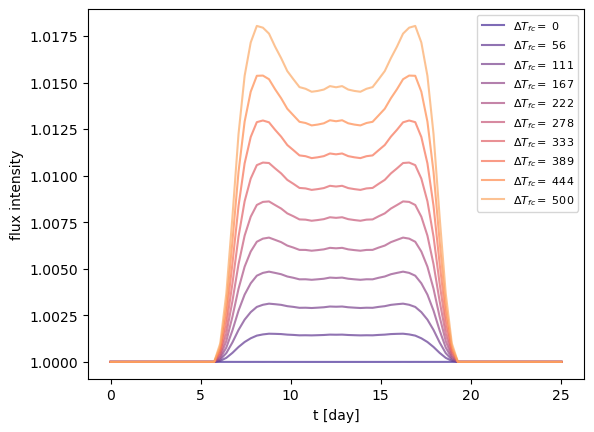

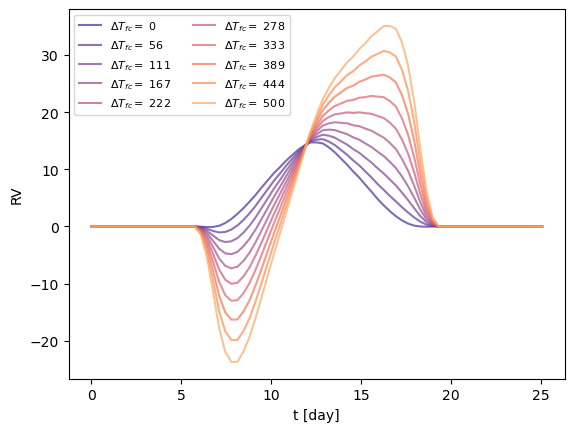

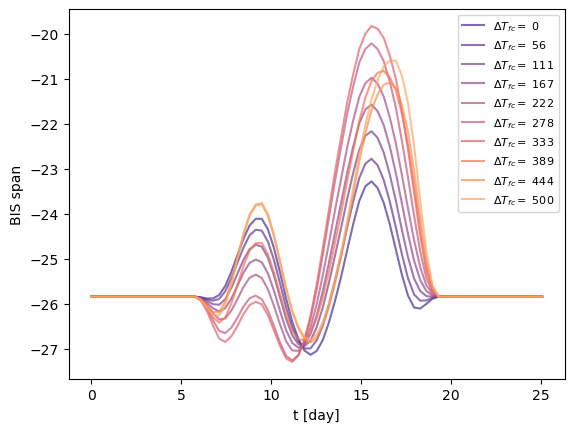

In [4]:
t=np.linspace(0,ss.rotation_period*periods_nbr,len(flux_vs_dT[0]))

plt.rcParams['font.size'] = 10
for i in range(len(flux_vs_dT)):
    plt.plot(t, flux_vs_dT[i], color=colors[i], alpha=0.7, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))
    
plt.xlabel('t [day]')
plt.ylabel('flux intensity')
plt.legend(fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/flux_vs_dT_fc_T_eff_{:.0f}.pdf'.format(ss.temperature_photosphere), dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(flux_vs_dT)):
    plt.plot(t, RV_vs_dT[i], color=colors[i], alpha=0.7, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))
    
plt.xlabel('t [day]')
plt.ylabel('RV')
plt.legend(ncol=2, fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/RV_vs_dT_fc_T_eff_{:.0f}.pdf'.format(ss.temperature_photosphere), dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(flux_vs_dT)):
    plt.plot(t, BIS_vs_dT[i], color=colors[i], alpha=0.7, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))
    
plt.xlabel('t [day]')
plt.ylabel('BIS span')
plt.legend(ncol=1, fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/BIS_vs_dT_fc_T_eff_{:.0f}.pdf'.format(ss.temperature_photosphere), dpi=200, bbox_inches='tight')
plt.show()

In [6]:
def C_starsim(mu, T_quiet, dT_fc):
    return ((T_quiet + 250.9-407.7*mu+190.9*mu**2 ) / (T_quiet + dT_fc))**4

def C_new(mu, T_quiet, dT_fc):
    return ((T_quiet + (250.9-407.7*mu+190.9*mu**2) * (dT_fc / 34.1)) / T_quiet)**4

def C_new_1(mu, T_quiet, dT_fc):
    return ((T_quiet + (250.9-407.7*mu+190.9*mu**2) * (dT_fc / 250.9)) / T_quiet)**4

def C_new_2(mu, T_quiet, dT_fc):
    return ((5778 + (250.9-407.7*mu+190.9*mu**2) * ((T_quiet + dT_fc) / 5808)) / T_quiet)**4

def C_new_3(mu, T_quiet, dT_fc):
    return ((5778 + (250.9-407.7*mu+190.9*mu**2)) / 5778)**4 * ((T_quiet + dT_fc )/ 5808)**4

def C_spec_600(mu, T_quiet, dT_fc):
    return 1 + (1-mu) * 71.190 * (dT_fc / 30.0) * (5778.0 / T_quiet)**2 * (1 / 6000)

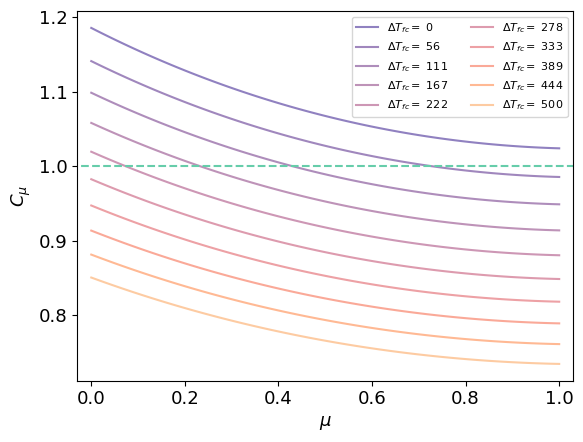

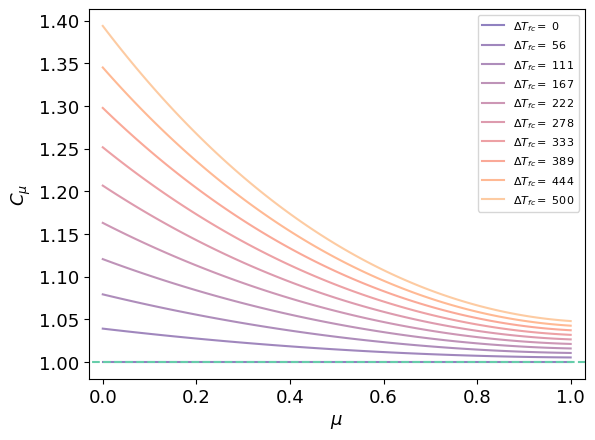

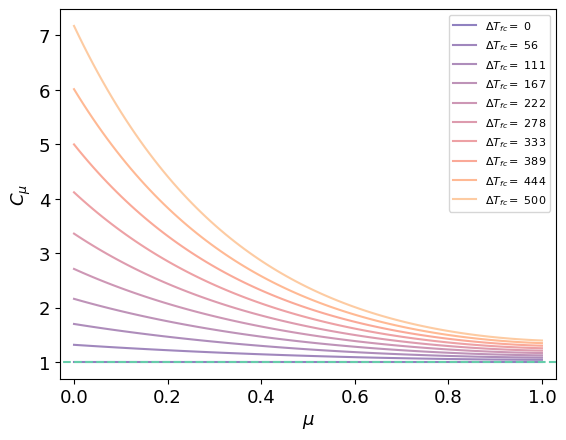

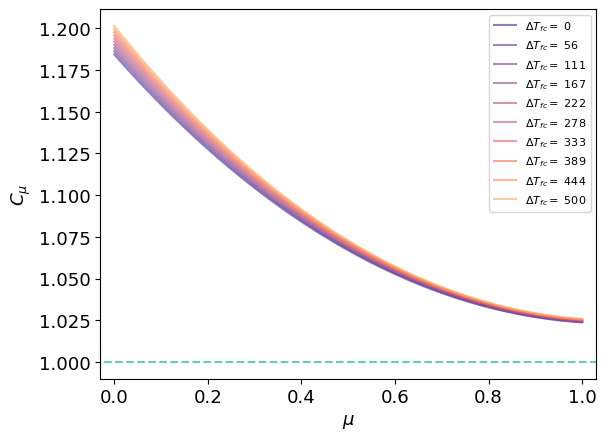

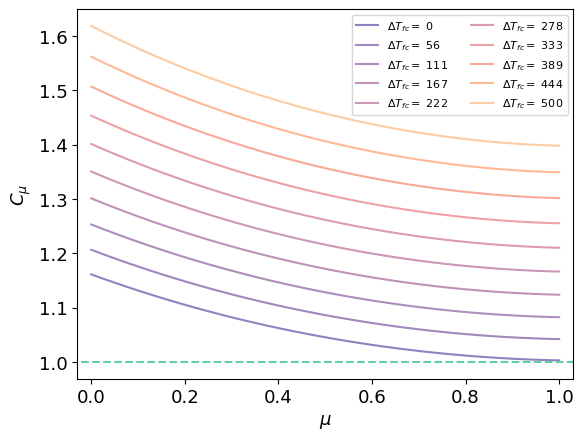

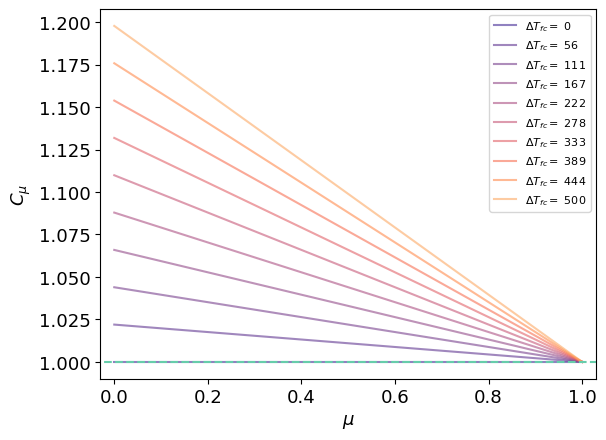

In [18]:
T_quiet = 5778
dT_fc = 30

plt.rcParams['font.size'] = 13

mu = np.linspace(0, 1, 100)

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_starsim(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend(fontsize=8, ncol=2)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrast_starsim.pdf', dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_new_1(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend(fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrast_new_1.pdf', dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_new(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend(fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrast_new.pdf', dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_new_2(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend(fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrast_new_2.pdf', dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_new_3(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend(fontsize=8, ncol=2)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrast_new_3.pdf', dpi=200, bbox_inches='tight')
plt.show()

for i in range(len(dT_fc_list)):
    plt.plot(mu, C_spec_600(mu, T_quiet, dT_fc_list[i]), color=colors[i], alpha=0.6, label='$\Delta T_{fc}=$ '+'{0:.0f}'.format(dT_fc_list[i]))

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend(fontsize=8)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrast_gondouin.pdf', dpi=200, bbox_inches='tight')
plt.show()

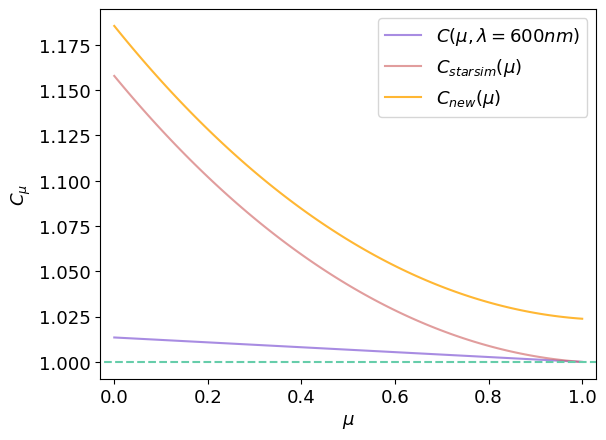

In [10]:
plt.plot(mu, C_spec_600(mu, T_quiet, 34.1), alpha=0.8, label='$C(\mu,\lambda=600 nm)$', color='mediumpurple')
plt.plot(mu, C_starsim(mu, T_quiet, 34.1), alpha=0.6, label='$C_{starsim}(\mu)$', color='indianred')
plt.plot(mu, C_new(mu, T_quiet, 34.1), alpha=0.8, label='$C_{new}(\mu)$', color='orange')

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend()
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrasts.pdf', dpi=200, bbox_inches='tight')
plt.show()

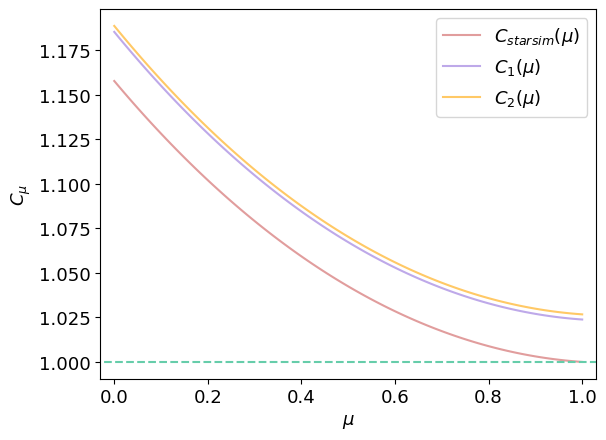

In [16]:
plt.plot(mu, C_starsim(mu, T_quiet, 34.1), alpha=0.6, label='$C_{starsim}(\mu)$', color='indianred')
plt.plot(mu, C_new_1(mu, T_quiet, 250.9), alpha=0.6, label='$C_1(\mu)$', color='mediumpurple')
plt.plot(mu, C_new_3(mu, T_quiet, 34.1), alpha=0.6, label='$C_{2}(\mu)$', color='orange')

plt.hlines(1, -0.07,1.07, linestyles='--', color='mediumaquamarine')
plt.xlim(-0.03,1.03)
plt.xlabel('$\mu$')
plt.ylabel('$C_{\mu}$')
plt.legend()
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/contrasts_2.pdf', dpi=200, bbox_inches='tight')
plt.show()

In [11]:
C_spec_600(0,5778,250.9) - C_spec_600(1,5778,250.9)

0.09923094999999993